# quick check external data

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


## events

In [2]:
events = pd.read_csv('external_data/event_data.csv', sep=';')

events.info()
print('--'*20)
display(events.sample(8))
print('Count Events:', events.event.nunique())
print('Events:', events.event.unique().tolist())

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    49 non-null     str  
 1   event   49 non-null     str  
dtypes: str(2)
memory usage: 2.2 KB
----------------------------------------


,date,event
28,2025-07-02,CHIO Aachen
20,2025-11-25,Karrieretag Aachen
25,2025-06-29,CHIO Aachen
26,2025-06-30,CHIO Aachen
4,2025-09-22,Stadtfest
10,2025-03-22,EUREGIO Wirtschaftsschau
11,2025-03-23,EUREGIO Wirtschaftsschau
30,2025-07-04,CHIO Aachen


Count Events: 7
Events: ['Stadtfest', 'WeinAachen', 'EUREGIO Wirtschaftsschau', 'Karrieretag Aachen', 'vocatium Aachen', 'CHIO Aachen', 'EUREGIO Wirtschaftsschau 2026']


In [36]:
# mapping zipcode

mapping = {
    "Stadtfest": "52062",
    "WeinAachen": "52062",
    "EUREGIO Wirtschaftsschau": "52070",
    "Karrieretag Aachen": "52062",
    "vocatium Aachen": "52062",
    "CHIO Aachen": "52070",
    "EUREGIO Wirtschaftsschau 2026": "52070",
}

events['zipcode'] = events.event.map(mapping)
display(events.sort_values('date'))
events.zipcode.unique()

,date,event,zipcode
8,2025-03-15,WeinAachen,52062
9,2025-03-16,WeinAachen,52062
10,2025-03-22,EUREGIO Wirtschaftsschau,52070
11,2025-03-23,EUREGIO Wirtschaftsschau,52070
12,2025-03-24,EUREGIO Wirtschaftsschau,52070
13,2025-03-25,EUREGIO Wirtschaftsschau,52070
14,2025-03-26,EUREGIO Wirtschaftsschau,52070
15,2025-03-27,EUREGIO Wirtschaftsschau,52070
16,2025-03-28,EUREGIO Wirtschaftsschau,52070
17,2025-03-29,EUREGIO Wirtschaftsschau,52070


<ArrowStringArray>
['52062', '52070']
Length: 2, dtype: str

## football

In [9]:
football_raw = pd.read_csv('external_data/football.csv', sep=',', index_col=0)
# scheinen auswärtsspiele zu sein
display(football_raw.sort_values('matchDateTime').head(2))
# plz stadion 52070
football = football_raw[['matchDateTime', 'team2.shortName' ]]
football['zipcode'] = 52070

,matchID,matchDateTime,timeZoneID,leagueId,leagueName,leagueSeason,leagueShortcut,matchDateTimeUTC,lastUpdateDateTime,matchIsFinished,...,team1.teamIconUrl,team1.teamGroupName,team2.teamId,team2.teamName,team2.shortName,team2.teamIconUrl,team2.teamGroupName,location.locationID,location.locationCity,location.locationStadium
14,78269,2025-08-09T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-09T12:00:00Z,2025-08-10T15:13:35.52,True,...,https://upload.wikimedia.org/wikipedia/commons...,NaN,2396,TSG 1899 Hoffenheim II,TSG 1899 Hoffenheim II,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN
24,78281,2025-08-23T14:00:00,W. Europe Standard Time,4857,3. Liga 2025/2026,2025,bl3,2025-08-23T12:00:00Z,2025-08-23T17:19:52.08,True,...,https://upload.wikimedia.org/wikipedia/commons...,NaN,125,TSV 1860 München,1860 München,https://upload.wikimedia.org/wikipedia/commons...,NaN,NaN,NaN,NaN


In [12]:
football.head()

,matchDateTime,team2.shortName,zipcode,home_game
14,2025-08-09T14:00:00,TSG 1899 Hoffenheim II,52070,1
24,2025-08-23T14:00:00,1860 München,52070,1
46,2025-09-13T16:30:00,SSV Ulm 1846,52070,1
64,2025-09-20T14:00:00,Mannheim,52070,1
84,2025-09-30T19:00:00,Aue,52070,1


## oil price

In [ ]:
oil_price = pd.read_csv('external_data/oil_price.csv')
oil_price = oil_price[2:].rename(columns={'Price': 'Date'})
oil_price.info()
oil_price.Date.max()
oil_price.head()
print('std:', oil_price.High.astype('float64').std())
# volume?

In [19]:
oil_price['Date'] = pd.to_datetime(oil_price['Date'])
oil_price['High'] = oil_price['High'].astype('float64')

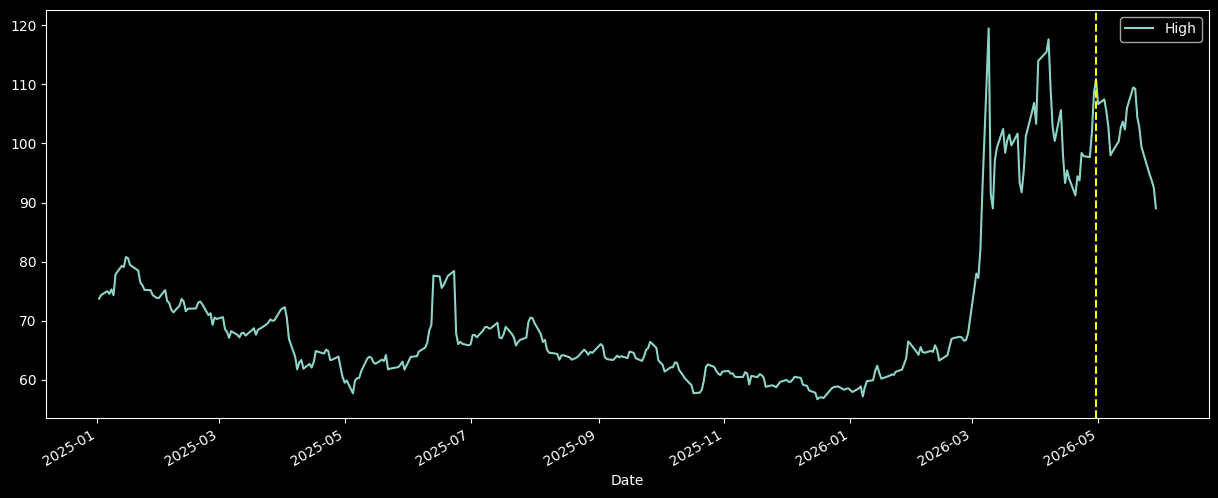

In [28]:
plt.style.use('dark_background')
oil_price.plot(kind='line', x='Date', y='High', figsize=(15,6))
plt.axvline('2026-04-30', linestyle="--", color='yellow')
plt.show()

In [5]:
vpidx = pd.read_csv('external_data/Verbraucherpreisindex.csv', skiprows=0, nrows=16, sep=';', header=4)
vpidx.info()
vpidx.rename(columns={'Unnamed: 0': 'Jahr', 'Unnamed: 1': 'Monat'})

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Jahr                              15 non-null     float64
 1   Monat                             15 non-null     str    
 2   Verbraucherpreisindex             16 non-null     str    
 3   Verbraucherpreisindex.1           16 non-null     str    
 4   Veränderung zum Vorjahresmonat    16 non-null     str    
 5   Veränderung zum Vorjahresmonat.1  16 non-null     str    
 6   Veränderung zum Vormonat          16 non-null     str    
 7   Veränderung zum Vormonat.1        14 non-null     str    
dtypes: float64(1), str(7)
memory usage: 1.5 KB


,Jahr,Monat,Verbraucherpreisindex,Verbraucherpreisindex.1,Veränderung zum Vorjahresmonat,Veränderung zum Vorjahresmonat.1,Veränderung zum Vormonat,Veränderung zum Vormonat.1
0,NaN,NaN,2020=100,2020=100,in (%),in (%),in (%),in (%)
1,2025.0,Januar,"120,3",e,"2,3",e,"-0,2",e
2,2025.0,Februar,"120,8",e,"2,3",e,"0,4",e
3,2025.0,März,"121,2",e,"2,2",e,"0,3",e
4,2025.0,April,"121,7",e,"2,1",e,"0,4",e
5,2025.0,Mai,"121,8",e,"2,1",e,"0,1",e
6,2025.0,Juni,"121,8",e,2,e,-,NaN
7,2025.0,Juli,"122,2",e,2,e,"0,3",e
8,2025.0,August,"122,3",e,"2,2",e,"0,1",e
9,2025.0,September,"122,6",e,"2,4",e,"0,2",e


## simon

In [102]:
e = pd.read_csv('external_data/_repo_intake_review_NON_FINAL/13111-01-03-5-B_05.csv', skip_prows==10).e.head()

NameError: name 'skip_prows' is not defined

# test 1

In [12]:
test['eins'] = {}


test['eins']['zwei'] = {'1': 1}

test

{'eins': {'zwei': {'1': 1}}}

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Raw data

In [3]:
df_holidays = pd.read_parquet('20260218_144523_holidays.parquet', engine='pyarrow')
df_sales = pd.read_parquet('20260218_144523_sales_data.parquet', engine='pyarrow')
df_stores = pd.read_parquet('20260218_144523_stores.parquet', engine='pyarrow')
df_weather = pd.read_parquet('20260218_144523_weather.parquet', engine='pyarrow')

In [4]:
pd.set_option('display.max_columns', None)

# Tests

In [13]:
df_weather.head()


,date,time,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_code,weather_description,precip,humidity,visibility,pressure,cloudcover,heatindex,dewpoint,windchill,windgust,feelslike,chanceofrain,chanceofremdry,chanceofwindy,chanceofovercast,chanceofsunshine,chanceoffrost,chanceofhightemp,chanceoffog,chanceofsnow,chanceofthunder,uv_index
0,2025-04-01,20:00,41812,10.0,16.0,79.0,ENE,113,Clear,0.0,56.0,10.0,1024.0,0.0,10.0,1.0,7.0,32.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2025-04-01,21:00,41812,9.0,16.0,75.0,ENE,113,Clear,0.0,60.0,10.0,1024.0,1.0,9.0,1.0,6.0,32.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-04-01,22:00,41812,9.0,18.0,71.0,ENE,113,Clear,0.0,62.0,10.0,1025.0,0.0,9.0,2.0,6.0,33.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-04-01,23:00,41812,8.0,20.0,70.0,ENE,113,Clear,0.0,63.0,10.0,1025.0,2.0,8.0,2.0,5.0,35.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2025-04-01,00:00,41812,6.0,10.0,52.0,NE,113,Clear,0.0,74.0,10.0,1028.0,0.0,6.0,2.0,4.0,21.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [18]:

df_weather.chanceofhightemp.nunique()

1

In [ ]:
rolls = df_sales.category_name.str.contains('Brötchen')
df_sales.loc[rolls, ['category_name']].value_counts()

In [ ]:
plt.figure(figsize=(13,8))

x = df_stores.groupby('store_id')['store_id'].sum()
y = df_stores.average_weekly_revenue_Q1.sort_values(ascending=False)
avg = df_stores.average_weekly_revenue_Q1.median()

plt.bar(x, y, align='edge', color='grey')
plt.plot((x.min(), x.max()), (avg, avg), '-k', lw=3, label='Median')

plt.xlim(0, 61)
plt.legend()
plt.show()

print(avg)

In [1]:
df_sales.head()

NameError: name 'df_sales' is not defined